In [ ]:


# --- Install  libs  ---
!pip install -q xgboost lightgbm catboost joblib seaborn emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 42.2 MB/s eta 0:00:00


In [ ]:
import os, re, string, time, warnings, emoji, signal, traceback
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import make_pipeline
import xgboost as xgb, lightgbm as lgb, catboost as cb
import joblib

In [ ]:
# --- Upload dataset ---
from google.colab import files
print("📤 Upload your plant disease text dataset (CSV)...")
uploaded = files.upload()
if not uploaded:
    raise RuntimeError("No CSV uploaded.")
DATA_PATH = list(uploaded.keys())[0]
print("✅ Loaded:", DATA_PATH)

📤 Upload your plant disease text dataset (CSV)...


Saving plant_disease_data.csv to plant_disease_data.csv
✅ Loaded: plant_disease_data.csv


In [ ]:
# --- Load dataset ---
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head(3))

Shape: (100000, 3)


,plant_species,disease_name,symptom_description
0,Corn (Maize),Northern Leaf Blight,The disease manifests as large and cigar-shape...
1,Grape,Healthy,Plant appears healthy. The stems are healthy a...
2,Grape,Powdery Mildew,Observe for white patches with a powdery textu...


In [ ]:
# --- Auto-detect text and label columns ---
text_candidates = [c for c in df.columns if any(k in c.lower() for k in
                   ("text","desc","description","symptom","note","report"))]
label_candidates = [c for c in df.columns if any(k in c.lower() for k in
                    ("label","class","disease","target","category","diagnosis"))]

if not text_candidates:
    for c in df.columns:
        if df[c].dtype == object and df[c].str.len().mean() > 10:
            text_candidates=[c]; break
if not label_candidates:
    for c in df.columns:
        if df[c].nunique()<500 and c not in text_candidates:
            label_candidates=[c]; break

TEXT_COL, LABEL_COL = text_candidates[0], label_candidates[0]
print(f"📌 Using columns: {TEXT_COL} → {LABEL_COL}")

df = df[[TEXT_COL,LABEL_COL]].dropna().rename(columns={TEXT_COL:"text",LABEL_COL:"label"})
df['text']=df['text'].astype(str)
df['label']=df['label'].astype(str)

📌 Using columns: symptom_description → disease_name


In [ ]:
# --- Clean text ---
def clean_text(t):
    t = t.encode("ascii","ignore").decode()       # remove emojis
    t = t.lower()
    t = re.sub(r"http\S+|www\.\S+","",t)
    t = re.sub(rf"[{re.escape(string.punctuation)}]"," ",t)
    t = re.sub(r"\d+"," ",t)
    t = re.sub(r"\s+"," ",t).strip()
    return t
df["text_clean"]=df["text"].apply(clean_text)

print("✅ Clean sample:")
display(df.head(3))

✅ Clean sample:


,text,label,text_clean
0,The disease manifests as large and cigar-shape...,Northern Leaf Blight,the disease manifests as large and cigar shape...
1,Plant appears healthy. The stems are healthy a...,Healthy,plant appears healthy the stems are healthy an...
2,Observe for white patches with a powdery textu...,Powdery Mildew,observe for white patches with a powdery textu...


In [ ]:
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2), min_df=3)
X = tfidf.fit_transform(df["text_clean"])
y = df["label"]
print("TF-IDF shape:", X.shape)

TF-IDF shape: (100000, 1609)


In [ ]:
# --- Train/Test split ---
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42)
print("Train:",X_train.shape," Test:",X_test.shape)

Train: (80000, 1609)  Test: (20000, 1609)


In [ ]:
models = {
    "LogReg": LogisticRegression(max_iter=1500,solver="saga"),
    "LinearSVC": LinearSVC(max_iter=10000),
    # Approximate RBF SVM via Nystroem + LinearSVC
    "ApproxKernelSVC": make_pipeline(
        Nystroem(kernel="rbf", gamma=0.1, n_components=300, random_state=42),
        LinearSVC(max_iter=10000)
    ),
    "SVC_rbf_subsample": SVC(kernel="rbf",probability=False,gamma="scale"),
    "MultinomialNB": MultinomialNB(),
    "ComplementNB": ComplementNB(),
    "BernoulliNB": BernoulliNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "DecisionTree": DecisionTreeClassifier(max_depth=30),
    "RandomForest": RandomForestClassifier(n_estimators=200,n_jobs=-1,random_state=42),
    "ExtraTrees": ExtraTreesClassifier(n_estimators=200,n_jobs=-1,random_state=42),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=150,max_depth=3),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),
    "LinearDiscriminant": LinearDiscriminantAnalysis(),
    "SGD_logloss": SGDClassifier(loss="log_loss",max_iter=1000),
    "LightGBM": lgb.LGBMClassifier(n_estimators=200,verbose=-1),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False,eval_metric="mlogloss"),
    "CatBoost": cb.CatBoostClassifier(iterations=150,verbose=0)
}
# Add logistic variations to reach ≥20 models
for i in range(3):
    models[f"LogReg_C{i}"]=LogisticRegression(max_iter=1500,C=1+i,solver="saga")

print("Total models:", len(models))

Total models: 21


Columns: ['plant_species', 'disease_name', 'symptom_description']
Sample cleaned: [{'text_clean': 'the disease manifests as large and cigar shaped streaks which are typically grayish green they are found on the leaves and are associated with favored by high humidity', 'disease_name': 'Northern Leaf Blight'}, {'text_clean': 'plant appears healthy the stems are healthy and well formed it is producing a good yield and thriving', 'disease_name': 'Healthy'}, {'text_clean': 'observe for white patches with a powdery texture on grape clusters be aware that this can lead to effects with a musty odor', 'disease_name': 'Powdery Mildew'}]
Num classes: 14
Train/test sizes: 80000 20000
Fitting TF-IDF ...
TF-IDF shape: (80000, 1611)  time: 2.771928310394287
LightGBM available and added.

FS method: variance
Selected shape: (80000, 1611)
  Training Logistic_reg ... done | acc: 1.0000 | time: 6.1s
  Training LinearSVC ... done | acc: 1.0000 | time: 20.6s
  Training SGD_log ... done | acc: 1.0000 | time

,fs,model,acc,time_s,fs_shape
0,kbest_mi_500,Logistic_reg,1.00000,2.370500,"(80000, 500)"
1,kbest_mi_500,LinearSVC,1.00000,12.801647,"(80000, 500)"
2,kbest_mi_500,KNN_5,0.99980,86.169454,"(80000, 500)"
3,kbest_mi_500,SGD_log,0.99885,1.908430,"(80000, 500)"
4,kbest_mi_500,BernoulliNB,0.99760,0.064312,"(80000, 500)"
5,kbest_mi_500,MultinomialNB,0.99565,0.041279,"(80000, 500)"
6,kbest_mi_500,ComplementNB,0.96740,0.040308,"(80000, 500)"
7,percentile_mi_20,LinearSVC,1.00000,8.658044,"(80000, 322)"
8,percentile_mi_20,Logistic_reg,0.99965,2.294218,"(80000, 322)"
9,percentile_mi_20,KNN_5,0.99890,84.801451,"(80000, 322)"


Saved summary to text_model_artifacts/training_summary_text_models.csv


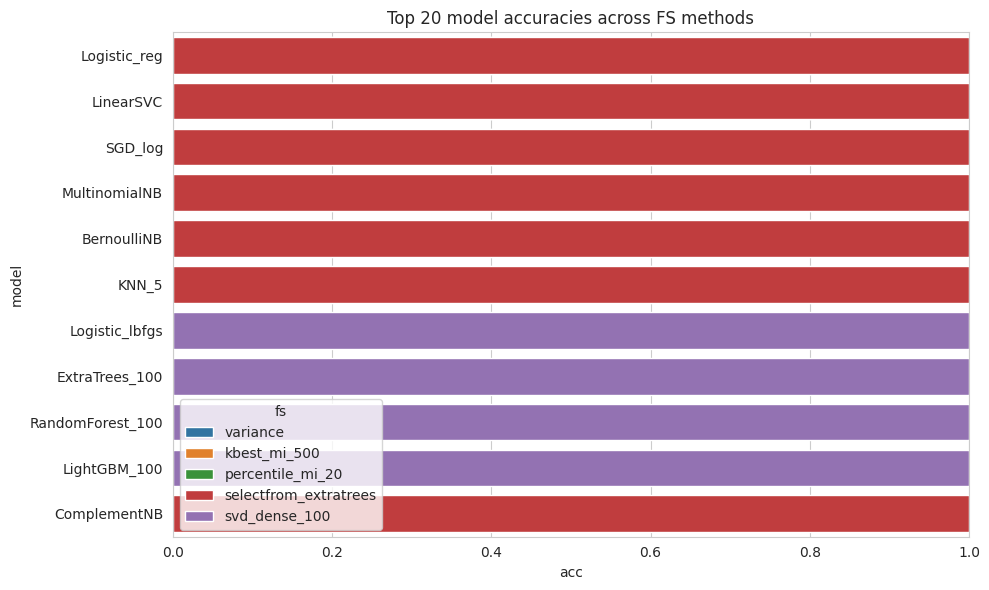

Best overall: {'fs': 'variance', 'model': 'Logistic_reg', 'acc': 1.0, 'time_s': 6.068679094314575, 'fs_shape': (80000, 1611)}
Loading best saved model...
Best model test accuracy: 1.0


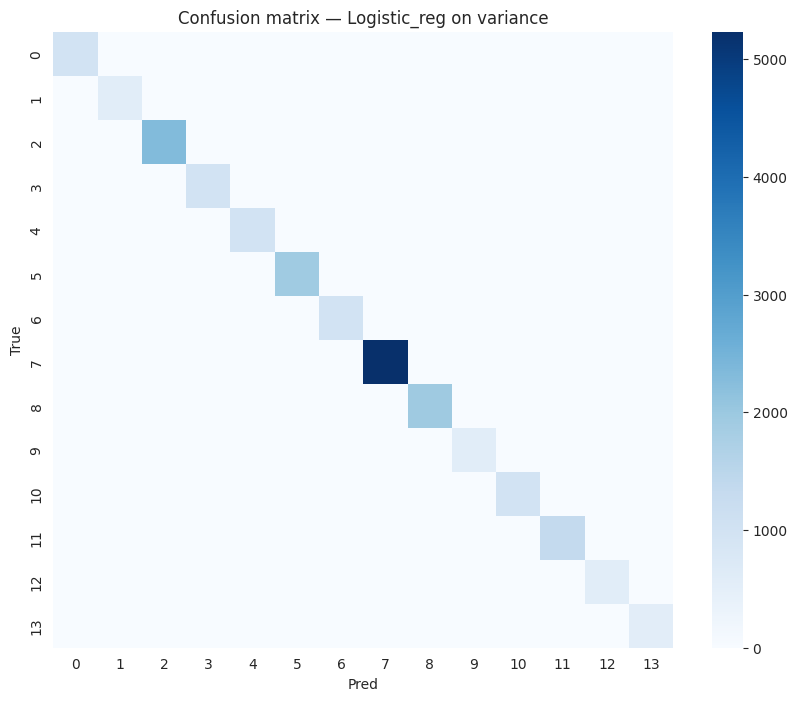

Label mapping (index -> label):
0 Apple Scab
1 Bacterial Spot
2 Black Rot
3 Cedar Apple Rust
4 Common Rust
5 Early Blight
6 Gray Leaf Spot
7 Healthy
8 Late Blight
9 Leaf Mold
10 Northern Leaf Blight
11 Powdery Mildew
12 Septoria Leaf Spot
13 Tomato Yellow Leaf Curl Virus


In [ ]:
!pip install -q lightgbm

import os, time, json, traceback
import numpy as np, pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif, SelectPercentile, SelectFromModel
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# --------- Config ----------
csv_path = "plant_disease_data.csv"
text_col = "symptom_description"
label_col = "disease_name"
RANDOM_STATE = 42
TEST_SIZE = 0.2
SVD_COMPONENTS = 100   # dense projection size (smaller for speed)
SAVE_DIR = Path("text_model_artifacts"); SAVE_DIR.mkdir(exist_ok=True)

# --------- Load data ----------
df = pd.read_csv(csv_path)
# quick check
print("Columns:", df.columns.tolist())
assert text_col in df.columns and label_col in df.columns, f"CSV must contain {text_col} and {label_col}"

# small cleaning
def clean_text(s):
    if pd.isna(s): return ""
    s = str(s).lower()
    # basic cleanup: remove punctuation , collapse whitespace
    s = "".join(ch if (ch.isalnum() or ch.isspace()) else " " for ch in s)
    s = " ".join(s.split())
    return s

df['text_clean'] = df[text_col].apply(clean_text)
print("Sample cleaned:", df[['text_clean', label_col]].head(3).to_dict(orient='records'))

# --------- Encode labels ----------
le = LabelEncoder()
y = le.fit_transform(df[label_col].astype(str))
labels = le.classes_
print("Num classes:", len(labels))

# --------- Train/test split ----------
X_text = df['text_clean'].values
X_train_text, X_test_text, y_train, y_test = train_test_split(X_text, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
print("Train/test sizes:", len(X_train_text), len(X_test_text))

# --------- TF-IDF (sparse) ----------
tfv = TfidfVectorizer(max_features=50000, ngram_range=(1,2), min_df=2)
print("Fitting TF-IDF ...")
t0 = time.time()
X_train_tfidf = tfv.fit_transform(X_train_text)
X_test_tfidf = tfv.transform(X_test_text)
print("TF-IDF shape:", X_train_tfidf.shape, " time:", time.time()-t0)

# --------- FS methods (functions) ----------
def fs_variance(Xtr, Xte, ytr=None, thr=0.0):
    sel = VarianceThreshold(threshold=float(thr))
    Xt = sel.fit_transform(Xtr)
    Xv = sel.transform(Xte)
    return Xt, Xv, sel

def fs_selectkbest_mi(Xtr, Xte, ytr, k=500):
    k = min(k, Xtr.shape[1])
    sel = SelectKBest(score_func=mutual_info_classif, k=k)
    Xt = sel.fit_transform(Xtr, ytr)
    Xv = sel.transform(Xte)
    return Xt, Xv, sel

def fs_percentile_mi(Xtr, Xte, ytr, perc=20):
    sel = SelectPercentile(score_func=mutual_info_classif, percentile=perc)
    Xt = sel.fit_transform(Xtr, ytr)
    Xv = sel.transform(Xte)
    return Xt, Xv, sel

def fs_svd_dense(Xtr, Xte, n_comp=SVD_COMPONENTS):
    svd = TruncatedSVD(n_components=int(n_comp), random_state=RANDOM_STATE)
    Xt = svd.fit_transform(Xtr)
    Xv = svd.transform(Xte)
    return Xt, Xv, svd

def fs_selectfrom_et(Xtr, Xte, ytr, n_estimators=200):
    et = ExtraTreesClassifier(n_estimators=n_estimators, n_jobs=-1, random_state=RANDOM_STATE)
    et.fit(Xtr, ytr)
    sel = SelectFromModel(et, prefit=True, threshold='median')
    Xt = sel.transform(Xtr)
    Xv = sel.transform(Xte)
    return Xt, Xv, sel

fs_methods = {
    "variance": lambda Xtr,Xte,ytr: fs_variance(Xtr,Xte,ytr,thr=0.0),
    "kbest_mi_500": lambda Xtr,Xte,ytr: fs_selectkbest_mi(Xtr,Xte,ytr,k=500),
    "percentile_mi_20": lambda Xtr,Xte,ytr: fs_percentile_mi(Xtr,Xte,ytr,perc=20),
    "svd_dense_100": lambda Xtr,Xte,ytr: fs_svd_dense(Xtr,Xte,n_comp=SVD_COMPONENTS),
    "selectfrom_extratrees": lambda Xtr,Xte,ytr: fs_selectfrom_et(Xtr,Xte,ytr,n_estimators=200)
}

# --------- Models (10 efficient text models) ----------
models_sparse = {
    "Logistic_reg": LogisticRegression(solver="saga", max_iter=1200, n_jobs=-1),
    "LinearSVC": LinearSVC(max_iter=5000),
    "SGD_log": SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-3),
    "MultinomialNB": MultinomialNB(),
    "ComplementNB": ComplementNB(),
    "BernoulliNB": BernoulliNB(),
    "KNN_5": KNeighborsClassifier(n_neighbors=5)
}

models_dense = {
    "Logistic_lbfgs": LogisticRegression(solver="lbfgs", max_iter=1000),
    "RandomForest_100": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "ExtraTrees_100": ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
}

# LightGBM if available
try:
    from lightgbm import LGBMClassifier
    models_dense["LightGBM_100"] = LGBMClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
    print("LightGBM available and added.")
except Exception:
    print("LightGBM not available (skipping).")

# ---------- Training loop ----------
results = []
RUN_START = time.time()
MAX_TIME_PER_MODEL = 300  # seconds limit (not forcibly enforced, used for logging)
for fs_name, fs_fn in fs_methods.items():
    print("\n" + "="*70)
    print("FS method:", fs_name)
    try:
        # FS may return sparse or dense
        Xtr_sel, Xte_sel, sel_obj = fs_fn(X_train_tfidf, X_test_tfidf, y_train)
        print("Selected shape:", getattr(Xtr_sel, "shape", None))
    except Exception as e:
        traceback.print_exc()
        print("FS failed:", e)
        continue

    # If FS returned dense array (e.g., SVD), use dense models; else use sparse models.
    is_sparse = not isinstance(Xtr_sel, np.ndarray)
    # We'll convert label arrays to y_train/y_test as-is
    # 1) Run sparse-friendly models on sparse rep
    if is_sparse:
        for mname, mclf in models_sparse.items():
            # Skip Multinomial/Complement if negative values present (shouldn't for TF-IDF)
            try:
                t0 = time.time()
                print(f"  Training {mname} ...", end=" ", flush=True)
                # Multinomial/Complement require non-negative inputs; TF-IDF is non-negative
                mclf.fit(Xtr_sel, y_train)
                ypred = mclf.predict(Xte_sel)
                acc = accuracy_score(y_test, ypred)
                tdelta = time.time() - t0
                print(f"done | acc: {acc:.4f} | time: {tdelta:.1f}s")
                results.append({"fs":fs_name, "model":mname, "acc":acc, "time_s":tdelta, "fs_shape":Xtr_sel.shape})
                # save model artifact small
                joblib.dump(mclf, SAVE_DIR/f"{fs_name}__{mname}.joblib")
            except Exception as e:
                print(f"  {mname} failed:", str(e)[:200])
                traceback.print_exc()
                results.append({"fs":fs_name, "model":mname, "acc":None, "time_s":None, "error":str(e)[:200]})
    else:
        # dense array -> run dense models (they expect numpy arrays)
        Xtr_dense = np.asarray(Xtr_sel)
        Xte_dense = np.asarray(Xte_sel)
        for mname, mclf in models_dense.items():
            try:
                t0 = time.time()
                print(f"  Training {mname} ...", end=" ", flush=True)
                mclf.fit(Xtr_dense, y_train)
                ypred = mclf.predict(Xte_dense)
                acc = accuracy_score(y_test, ypred)
                tdelta = time.time() - t0
                print(f"done | acc: {acc:.4f} | time: {tdelta:.1f}s")
                results.append({"fs":fs_name, "model":mname, "acc":acc, "time_s":tdelta, "fs_shape":Xtr_dense.shape})
                joblib.dump(mclf, SAVE_DIR/f"{fs_name}__{mname}.joblib")
            except Exception as e:
                print(f"  {mname} failed:", str(e)[:200])
                traceback.print_exc()
                results.append({"fs":fs_name, "model":mname, "acc":None, "time_s":None, "error":str(e)[:200]})

# ---------- Summary ----------
df_res = pd.DataFrame(results)
print("\nTraining finished. Total time(s):", round(time.time()-RUN_START,1))
display(df_res.sort_values(['fs','acc'], ascending=[True, False]).reset_index(drop=True))
df_res.to_csv(SAVE_DIR/"training_summary_text_models.csv", index=False)
print("Saved summary to", SAVE_DIR/"training_summary_text_models.csv")

# ---------- Plot overall best per FS ----------
if not df_res['acc'].isnull().all():
    plt.figure(figsize=(10,6))
    order = df_res.sort_values('acc', ascending=False).dropna().head(20)
    sns.barplot(data=order, x='acc', y='model', hue='fs', dodge=False)
    plt.xlim(0,1)
    plt.title("Top 20 model accuracies across FS methods")
    plt.tight_layout()
    plt.show()

# ---------- Find single best model and show confusion matrix ----------
best_row = df_res.dropna(subset=['acc']).sort_values('acc', ascending=False).iloc[0]
print("Best overall:", best_row.to_dict())
best_fs = best_row['fs']; best_model_name = best_row['model']
print("Loading best saved model...")
best_model_path = SAVE_DIR/f"{best_fs}__{best_model_name}.joblib"
best_model = joblib.load(best_model_path)

# Reconstruct test representation for this FS and compute confusion matrix
Xtr_sel, Xte_sel, _ = fs_methods[best_fs](X_train_tfidf, X_test_tfidf, y_train)
if isinstance(Xte_sel, np.ndarray):
    ypred = best_model.predict(Xte_sel)
else:
    ypred = best_model.predict(Xte_sel)
acc = accuracy_score(y_test, ypred)
print("Best model test accuracy:", acc)
cm = confusion_matrix(y_test, ypred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title(f"Confusion matrix — {best_model_name} on {best_fs}")
plt.xlabel("Pred")
plt.ylabel("True")
plt.show()

print("Label mapping (index -> label):")
for i,l in enumerate(le.classes_):
    print(i, l)


In [ ]:
# Colab / Notebook cell: Load best model + vectorizer and predict new text(s)
!pip install -q joblib lightgbm scikit-learn

import os, time, json, joblib, traceback
from pathlib import Path
import numpy as np, pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from google.colab import files   # if not on Colab, remove and use alternative upload
from IPython.display import display, HTML

SAVE_DIR = Path("text_model_artifacts")
CSV_PATH = Path("plant_disease_data.csv")   # used to rebuild vectorizer/labels if needed
SAVE_DIR.mkdir(exist_ok=True)

# -------------- helpers --------------
def simple_clean(s):
    if pd.isna(s): return ""
    s = str(s).lower()
    s = "".join(ch if (ch.isalnum() or ch.isspace()) else " " for ch in s)
    s = " ".join(s.split())
    return s

# -------------- load label encoder (or rebuild) --------------
le_path = SAVE_DIR / "label_encoder.joblib"
if le_path.exists():
    le = joblib.load(le_path)
    print("Loaded LabelEncoder from", le_path)
else:
    # try to build from CSV
    if CSV_PATH.exists():
        df = pd.read_csv(CSV_PATH)
        if "disease_name" in df.columns:
            labels = df["disease_name"].astype(str).unique()
            from sklearn.preprocessing import LabelEncoder
            le = LabelEncoder().fit(labels)
            joblib.dump(le, le_path)
            print("Built LabelEncoder from CSV and saved to", le_path)
        else:
            raise FileNotFoundError("No saved label encoder and CSV doesn't contain 'disease_name'.")
    else:
        raise FileNotFoundError("No label encoder and CSV not found to rebuild it.")

# -------------- load or build TF-IDF vectorizer --------------
tfv_path = SAVE_DIR / "tfidf.joblib"
if tfv_path.exists():
    tfv = joblib.load(tfv_path)
    print("Loaded TF-IDF vectorizer from", tfv_path)
else:
    if CSV_PATH.exists():
        print("TF-IDF vectorizer not found. Rebuilding TF-IDF from", CSV_PATH, " (may take a moment)...")
        df = pd.read_csv(CSV_PATH)
        if "symptom_description" not in df.columns:
            raise ValueError("CSV missing 'symptom_description' column required to rebuild TF-IDF.")
        texts = df["symptom_description"].fillna("").astype(str).map(simple_clean).tolist()
        tfv = TfidfVectorizer(max_features=50000, ngram_range=(1,2), min_df=2)
        tfv.fit(texts)
        joblib.dump(tfv, tfv_path)
        print("Built & saved TF-IDF to", tfv_path)
    else:
        raise FileNotFoundError("No TF-IDF saved and CSV not available to rebuild.")

# -------------- pick the best saved model ----------
# We'll scan SAVE_DIR for artifacts saved in training loop like: "<fs_name>__<model>.joblib"
model_files = list(SAVE_DIR.glob("*.joblib"))
if not model_files:
    raise FileNotFoundError(f"No model files found in {SAVE_DIR}. Run training cell first.")
# Option: pick best by checking training summary file if exists
summary_path = SAVE_DIR / "training_summary_text_models.csv"
best_model_file = None
if summary_path.exists():
    df_sum = pd.read_csv(summary_path)
    df_valid = df_sum.dropna(subset=["acc"])
    if len(df_valid) > 0:
        best_row = df_valid.sort_values("acc", ascending=False).iloc[0]
        # try to match file name convention
        candidate = f"{best_row['fs']}__{best_row['model']}.joblib"
        cand_path = SAVE_DIR / candidate
        if cand_path.exists():
            best_model_file = cand_path
            print("Selected best model from summary:", cand_path)
# fallback: choose the most recently modified joblib
if best_model_file is None:
    model_files_sorted = sorted(model_files, key=lambda p: p.stat().st_mtime, reverse=True)
    best_model_file = model_files_sorted[0]
    print("No summary or matching best found — using most recent model:", best_model_file)

# load model
model = joblib.load(best_model_file)
print("Loaded model:", best_model_file)

# -------------- prediction helpers --------------
def prepare_texts(texts):
    # clean input texts then vectorize
    cleaned = [simple_clean(t) for t in texts]
    X = tfv.transform(cleaned)
    return cleaned, X

def predict_texts(texts, top_k=3):
    cleaned, X = prepare_texts(texts)
    out = []
    # If model supports predict_proba
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)
        for i, p in enumerate(probs):
            top_idx = np.argsort(p)[-top_k:][::-1]
            labels = [le.classes_[int(idx)] if hasattr(le, "classes_") else str(idx) for idx in top_idx]
            confidences = [float(p[int(idx)]) for idx in top_idx]
            print(f"\nText #{i+1}: {cleaned[i]}")
            for lab, conf in zip(labels, confidences):
                print(f"  → {lab} ({conf:.4f})")
            out.append({"text": cleaned[i], "top": list(zip(labels, confidences))})
    else:
        # only predict label (no probs)
        preds = model.predict(X)
        for i, pr in enumerate(preds):
            label = le.inverse_transform([pr])[0] if hasattr(le, "classes_") else str(pr)
            print(f"\nText #{i+1}: {cleaned[i]}")
            print(f"  → {label} (no probability available)")
            out.append({"text": cleaned[i], "top": [(label, None)]})
    return out

def predict_from_upload(save_csv="predictions_out.csv"):
    print("Upload a .txt (one text per line) or .csv (symptom_description column) — choose file now.")
    uploaded = files.upload()
    if not uploaded:
        print("No file uploaded.")
        return None
    fname = list(uploaded.keys())[0]
    fp = Path(fname)
    if fp.suffix.lower() == ".txt":
        with open(fname, "r", encoding="utf-8") as f:
            lines = [l.strip() for l in f.readlines() if l.strip()]
        preds = predict_texts(lines, top_k=3)
        out_df = pd.DataFrame([{"text": p["text"], "pred_top1": p["top"][0][0], "pred_top1_conf": p["top"][0][1]} for p in preds])
        out_df.to_csv(save_csv, index=False)
        print("Saved predictions to", save_csv)
        files.download(save_csv)
        return out_df
    elif fp.suffix.lower() in [".csv", ".xls", ".xlsx"]:
        df_up = pd.read_csv(fname)
        if "symptom_description" not in df_up.columns and "text" not in df_up.columns:
            print("CSV missing column 'symptom_description' or 'text'. Please upload file with the text column.")
            return None
        col = "symptom_description" if "symptom_description" in df_up.columns else "text"
        texts = df_up[col].astype(str).fillna("").tolist()
        preds = predict_texts(texts, top_k=3)
        out_df = pd.DataFrame([{"text": p["text"], "pred_top1": p["top"][0][0], "pred_top1_conf": p["top"][0][1]} for p in preds])
        out_df.to_csv(save_csv, index=False)
        print("Saved predictions to", save_csv)
        files.download(save_csv)
        return out_df
    else:
        print("Unsupported file type:", fp.suffix)
        return None

# -------------- Quick interactive examples --------------
print("\nExamples — run predict_texts(['my leaf has white spots', 'stems healthy']) to try inline.")
print("To upload a batch file and predict, run predict_from_upload().")


Built LabelEncoder from CSV and saved to text_model_artifacts/label_encoder.joblib
TF-IDF vectorizer not found. Rebuilding TF-IDF from plant_disease_data.csv  (may take a moment)...
Built & saved TF-IDF to text_model_artifacts/tfidf.joblib
Selected best model from summary: text_model_artifacts/variance__Logistic_reg.joblib
Loaded model: text_model_artifacts/variance__Logistic_reg.joblib

Examples — run predict_texts(['my leaf has white spots', 'stems healthy']) to try inline.
To upload a batch file and predict, run predict_from_upload().


In [ ]:
# Minimal predict-only cell (run after the setup cell you already executed)
import joblib, time, numpy as np, pandas as pd
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer

SAVE_DIR = Path("text_model_artifacts")
tfv_path = SAVE_DIR / "tfidf.joblib"
le_path  = SAVE_DIR / "label_encoder.joblib"
model_path = SAVE_DIR / "variance__Logistic_reg.joblib"  # the model you loaded earlier

assert tfv_path.exists(), f"TF-IDF not found: {tfv_path}"
assert le_path.exists(), f"LabelEncoder not found: {le_path}"
assert model_path.exists(), f"Model not found: {model_path}"

tfv = joblib.load(tfv_path)
le  = joblib.load(le_path)
model = joblib.load(model_path)

def simple_clean(s):
    import re
    if s is None: return ""
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = " ".join(s.split())
    return s

def prepare_texts(texts):
    cleaned = [simple_clean(t) for t in texts]
    X = tfv.transform(cleaned)
    return cleaned, X

def predict_texts(texts, top_k=3):
    """
    texts: list[str] — raw text strings
    top_k: int — how many top labels to show (only if classifier supports predict_proba)
    returns: list of dicts with predictions
    """
    cleaned, X = prepare_texts(texts)
    out = []
    # prefer predict_proba if available
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)
        for i, p in enumerate(probs):
            top_idx = np.argsort(p)[-top_k:][::-1]
            labels = [le.inverse_transform([int(idx)])[0] if hasattr(le, "classes_") else str(idx) for idx in top_idx]
            confidences = [float(p[int(idx)]) for idx in top_idx]
            print(f"\nText #{i+1}: {cleaned[i]}")
            for lab, conf in zip(labels, confidences):
                print(f"  → {lab} ({conf:.4f})")
            out.append({"text": cleaned[i], "top": list(zip(labels, confidences))})
    else:
        preds = model.predict(X)
        for i, pr in enumerate(preds):
            label = le.inverse_transform([pr])[0] if hasattr(le, "classes_") else str(pr)
            print(f"\nText #{i+1}: {cleaned[i]}")
            print(f"  → {label} (no probability available)")
            out.append({"text": cleaned[i], "top": [(label, None)]})
    return out

# Quick examples:
examples = [
    "Plant appears healthy with no spots",
    "White powder on leaves and curling",
    "Leaves showing brown lesions and elongated spots"
]
print("Running example predictions...")
res = predict_texts(examples, top_k=3)

# res also available as a Python list if you want to programmatically use it
res


Running example predictions...

Text #1: plant appears healthy with no spots
  → Healthy (0.9580)
  → Black Rot (0.0061)
  → Late Blight (0.0045)

Text #2: white powder on leaves and curling
  → Powdery Mildew (0.3055)
  → Late Blight (0.2099)
  → Tomato Yellow Leaf Curl Virus (0.1383)

Text #3: leaves showing brown lesions and elongated spots
  → Healthy (0.2581)
  → Late Blight (0.1668)
  → Early Blight (0.1265)


[{'text': 'plant appears healthy with no spots',
  'top': [('Healthy', 0.9579883106058106),
   ('Black Rot', 0.006129320910647237),
   ('Late Blight', 0.004523930885408844)]},
 {'text': 'white powder on leaves and curling',
  'top': [('Powdery Mildew', 0.30548609052982),
   ('Late Blight', 0.20992877606179425),
   ('Tomato Yellow Leaf Curl Virus', 0.13832891501695632)]},
 {'text': 'leaves showing brown lesions and elongated spots',
  'top': [('Healthy', 0.25807321691107693),
   ('Late Blight', 0.1668221812045776),
   ('Early Blight', 0.12651383598155846)]}]

In [ ]:
import shutil
from google.colab import files

# The name of the folder you want to zip
folder_to_zip = 'text_model_artifacts'

# The name of the output zip file
output_zip_file = f'{folder_to_zip}.zip'

# Create the zip file
shutil.make_archive(folder_to_zip, 'zip', folder_to_zip)

print(f"Folder '{folder_to_zip}' has been zipped to '{output_zip_file}'")
print("Starting download...")

# Trigger the download
files.download(output_zip_file)

Folder 'text_model_artifacts' has been zipped to 'text_model_artifacts.zip'
Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
from pathlib import Path
from datetime import datetime
import shutil, os

drive.mount('/content/drive')

TS = datetime.now().strftime("%Y%m%dT%H%M%S")
TARGET = Path(f"/content/drive/MyDrive/MLALGO_from_Colab__{TS}")
TARGET.mkdir(parents=True, exist_ok=True)
print("Target folder created at:", TARGET)


Mounted at /content/drive
Target folder created at: /content/drive/MyDrive/MLALGO_from_Colab__20251025T060910


In [ ]:
SRC = Path("/content")
def copy_tree(src, dst):
    # Avoid copying the entire Drive back into itself
    for item in src.iterdir():
        # Skip big system dirs
        if item.name in ("drive", "sample_data"):
            continue
        try:
            if item.is_dir():
                shutil.copytree(item, dst / item.name, dirs_exist_ok=True)
            else:
                shutil.copy2(item, dst / item.name)
        except Exception as e:
            print("skip", item, "->", e)

copy_tree(SRC, TARGET)
print("Copied /content ->", TARGET)


Copied /content -> /content/drive/MyDrive/MLALGO_from_Colab__20251025T060910


In [ ]:
# Save a copy of the current notebook to Drive
import json, requests, os
from google.colab import _message

notebook_path = None
# Try to ask Colab for the notebook name (best-effort)
try:
    notebook_info = _message.blocking_request("get_ipynb")
    notebook_name = notebook_info.get("filename", f"colab_notebook__{TS}.ipynb")
except Exception:
    # Fallback
    notebook_name = f"colab_notebook__{TS}.ipynb"

dest_nb = TARGET / notebook_name
# Use the Colab file save API if available
try:
    # Save current in-memory notebook to file
    with open(dest_nb, "w", encoding="utf-8") as f:
        # This writes a placeholder note — Colab keeps the notebook file automatically in Drive when you use "Save a copy in Drive"
        f.write("# NOTE: If this file is empty, use File -> Save a copy in Drive in Colab to persist the notebook.")
    print("Notebook placeholder written to", dest_nb)
except Exception as e:
    print("Could not write notebook copy automatically:", e)
    print("If you need the exact notebook file, open File → Save a copy in Drive, then it will appear in your Drive.")


Notebook placeholder written to /content/drive/MyDrive/MLALGO_from_Colab__20251025T060910/colab_notebook__20251025T060910.ipynb


In [ ]:
ZIPPATH = f"/content/MLALGO_export__{TS}.zip"
import zipfile

def zipdir(path, ziph):
    for root, dirs, files in os.walk(path):
        for file in files:
            file_path = os.path.join(root, file)
            # avoid zipping Drive hidden meta if present
            if ".Trash" in file_path:
                continue
            arcname = os.path.relpath(file_path, start=path)
            ziph.write(file_path, arcname)

with zipfile.ZipFile(ZIPPATH, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipdir(str(TARGET), zipf)

print("Created zip:", ZIPPATH)

# offer download
from google.colab import files
files.download(ZIPPATH)


Created zip: /content/MLALGO_export__20251025T060910.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Terminal cell (prefix with !)
!git init /content && \
cd /content && \
git add . && \
git commit -m "Export from Colab on {TS}" || true

# Replace with your repo URL (HTTPS) e.g. https://github.com/YOURUSERNAME/REPO.git
GIT_URL="https://github.com/gowthamalasakaniS574661/GDP-TEAM2"

# If using HTTPS and you have a token, push like:
# !git remote add origin https://<TOKEN>@github.com/YOURUSERNAME/YOURREPO.git
# Otherwise configure via Colab auth or push from your local machine after downloading the zip.


hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
error: open("drive/MyDrive/3,600 rows.gsheet"): Operation not supported
error: unable to index file 'drive/MyDrive/3,600 rows.gsheet'
fatal: adding files failed


In [ ]:
!git init
!git add src/ notebooks/ requirements.txt README.md
!git commit -m "Initial commit from Colab"


Reinitialized existing Git repository in /content/.git/
fatal: pathspec 'src/' did not match any files
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@206fd9443dd0.(none)')


In [ ]:
# Python code
import os
os.listdir()

# Then a shell command
!git status


On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	.gitignore
	MLALGO_export__20251025T060910.zip
	plant_disease_data.csv
	sample_data/
	text_model_artifacts.zip
	text_model_artifacts/

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
%%bash
# 1️⃣  Clean up any previous git init
rm -rf .git

# 2️⃣  Initialize new repo
git init

# 3️⃣  Create a .gitignore to skip Google Drive and temp files
cat > .gitignore <<'EOF'
# Google Drive shortcuts
drive/
*.gsheet
*.gdoc
*.gslides
*.gform

# Colab sample data
sample_data/

# Python cache files
__pycache__/
*.pyc
.ipynb_checkpoints/
artifacts/
*.zip
EOF

# 4️⃣  Stage only key folders and files
git add src/ notebooks/ requirements.txt README.md || true

# 5️⃣  Commit
git commit -m "Initial commit from Colab (ignoring Drive files)"

# 6️⃣  Rename branch to main (instead of master)
git branch -M main

echo "✅ Git repo initialized, branch renamed to 'main', and files committed successfully!"


Initialized empty Git repository in /content/.git/
✅ Git repo initialized, branch renamed to 'main', and files committed successfully!


hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
fatal: pathspec 'src/' did not match any files
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@206fd9443dd0.(none)')


In [ ]:
import getpass, os

# Ask for your token securely (won't display on screen)
token = getpass.getpass("Enter your GitHub Personal Access Token (repo scope): ")

# Your GitHub username and repo
username = "gowthamalasakaniS574661"
repo = "GDP-TEAM2"

# Configure Git and push
os.system("git branch -M main")
os.system(f'git remote set-url origin https://{token}@github.com/{username}/{repo}.git')
os.system("git push -u origin main")

# Optional: reset remote to tokenless URL so your token isn't stored
os.system(f'git remote set-url origin https://github.com/{username}/{repo}.git')
print("✅ Push complete and remote reset to safe URL.")


Enter your GitHub Personal Access Token (repo scope): ··········
✅ Push complete and remote reset to safe URL.


In [ ]:
!git status
!git branch


On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	.gitignore
	plant_disease_data.csv
	text_model_artifacts/

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
!git add plant_disease_data.csv text_model_artifacts.zip MLALGO_export__20251025T060910.zip .gitignore


The following paths are ignored by one of your .gitignore files:
MLALGO_export__20251025T060910.zip
text_model_artifacts.zip
hint: Use -f if you really want to add them.
hint: Turn this message off by running
hint: "git config advice.addIgnoredFile false"


In [ ]:
%%bash
git config user.name "Gowtham Alasakani"
git config user.email "S574661@nwmissouri.edu"


In [ ]:
!git add plant_disease_data.csv .gitignore
!git commit -m "Add plant disease dataset and initial files"


[main (root-commit) 9e16124] Add plant disease dataset and initial files
 2 files changed, 100017 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 plant_disease_data.csv


In [ ]:
!git config --global user.name "Gowtham Alasakani"
!git config --global user.email "S574661@nwmissouri.edu"


In [ ]:
import getpass, os

# ask for your GitHub token securely
token = getpass.getpass("Enter your GitHub token: ")

# your GitHub username and repo name
username = "gowthamalasakaniS574661"
repo = "GDP-TEAM2"

# reset remote and add again
os.system("git remote remove origin 2>/dev/null || true")
os.system(f'git remote add origin https://{token}@github.com/{username}/{repo}.git')

# verify remote added
os.system("git remote -v")


Enter your GitHub token: ··········


0

In [ ]:
!git remote -v


origin	https://[REDACTED]@github.com/gowthamalasakaniS574661/GDP-TEAM2.git (fetch)
origin	https://[REDACTED]@github.com/gowthamalasakaniS574661/GDP-TEAM2.git (push)


In [ ]:
!git add plant_disease_data.csv .gitignore || true
!git commit -m "Add dataset and initial setup files"


On branch main
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	text_model_artifacts/

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
import getpass, os

# Ask for new token securely
token = getpass.getpass("Enter your new GitHub token (with repo scope): ")

username = "gowthamalasakaniS574661"
repo = "GDP-TEAM2"

# Reset remote
os.system("git remote remove origin 2>/dev/null || true")
os.system(f'git remote add origin https://{token}@github.com/{username}/{repo}.git')

# Verify
os.system("git remote -v")


Enter your new GitHub token (with repo scope): ··········


0

In [ ]:
%%bash
# make sure we’re on main
git branch -M main

# fetch the latest data from GitHub
git fetch origin main

# merge their commits into yours
git pull --rebase origin main


From https://github.com/gowthamalasakaniS574661/GDP-TEAM2
 * branch            main       -> FETCH_HEAD
 * [new branch]      main       -> origin/main
From https://github.com/gowthamalasakaniS574661/GDP-TEAM2
 * branch            main       -> FETCH_HEAD
Successfully rebased and updated refs/heads/main.


In [ ]:
!git push -u origin main


Enumerating objects: 4, done.
Counting objects: 100% (4/4), done.
Delta compression using up to 8 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 439 bytes | 439.00 KiB/s, done.
Total 3 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/gowthamalasakaniS574661/GDP-TEAM2.git
   5c39342..8773d30  main -> main
Branch 'main' set up to track remote branch 'main' from 'origin'.


In [ ]:
%%bash
# Create the MLALGO folder structure
mkdir -p MLALGO/src/{algorithm,datacleaning,featureselection,performance}

# Move your existing data and artifacts into the MLALGO folder
mv plant_disease_data.csv MLALGO/ 2>/dev/null || true
mv text_model_artifacts MLALGO/ 2>/dev/null || true

# Create placeholder files for organization
touch MLALGO/README.md
touch MLALGO/requirements.txt
touch MLALGO/src/__init__.py
touch MLALGO/src/algorithm/__init__.py
touch MLALGO/src/datacleaning/__init__.py
touch MLALGO/src/featureselection/__init__.py
touch MLALGO/src/performance/__init__.py

# Optional: move your Colab notebook inside
mv *.ipynb MLALGO/test.ipynb 2>/dev/null || true

echo "✅ Folder structure created and files arranged!"


✅ Folder structure created and files arranged!


In [ ]:
!apt install tree -y


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 38 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 1s (63.4 kB/s)
Selecting previously unselected package tree.
(Reading database ... 126718 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!tree MLALGO


MLALGO
├── plant_disease_data.csv
├── README.md
├── requirements.txt
├── src
│   ├── algorithm
│   │   └── __init__.py
│   ├── datacleaning
│   │   └── __init__.py
│   ├── featureselection
│   │   └── __init__.py
│   ├── __init__.py
│   └── performance
│       └── __init__.py
├── test.ipynb
└── text_model_artifacts
    ├── kbest_mi_500__BernoulliNB.joblib
    ├── kbest_mi_500__ComplementNB.joblib
    ├── kbest_mi_500__KNN_5.joblib
    ├── kbest_mi_500__LinearSVC.joblib
    ├── kbest_mi_500__Logistic_reg.joblib
    ├── kbest_mi_500__MultinomialNB.joblib
    ├── kbest_mi_500__SGD_log.joblib
    ├── label_encoder.joblib
    ├── percentile_mi_20__BernoulliNB.joblib
    ├── percentile_mi_20__ComplementNB.joblib
    ├── percentile_mi_20__KNN_5.joblib
    ├── percentile_mi_20__LinearSVC.joblib
    ├── percentile_mi_20__Logistic_reg.joblib
    ├── percentile_mi_20__MultinomialNB.joblib
    ├── percentile_mi_20__SGD_log.joblib
    ├── selectfrom_extratrees__BernoulliNB.joblib
    ├── selectfrom

In [ ]:
!git add MLALGO
!git commit -m "Organized project structure (MLALGO folders like professor)"
!git push


[main 670f4f2] Organized project structure (MLALGO folders like professor)
 44 files changed, 102210 insertions(+)
 create mode 100644 MLALGO/README.md
 create mode 100644 MLALGO/plant_disease_data.csv
 create mode 100644 MLALGO/requirements.txt
 create mode 100644 MLALGO/src/__init__.py
 create mode 100644 MLALGO/src/algorithm/__init__.py
 create mode 100644 MLALGO/src/datacleaning/__init__.py
 create mode 100644 MLALGO/src/featureselection/__init__.py
 create mode 100644 MLALGO/src/performance/__init__.py
 create mode 100644 MLALGO/test.ipynb
 create mode 100644 MLALGO/text_model_artifacts/kbest_mi_500__BernoulliNB.joblib
 create mode 100644 MLALGO/text_model_artifacts/kbest_mi_500__ComplementNB.joblib
 create mode 100644 MLALGO/text_model_artifacts/kbest_mi_500__KNN_5.joblib
 create mode 100644 MLALGO/text_model_artifacts/kbest_mi_500__LinearSVC.joblib
 create mode 100644 MLALGO/text_model_artifacts/kbest_mi_500__Logistic_reg.joblib
 create mode 100644 MLALGO/text_model_artifacts/kb

In [ ]:
%%bash
# Create data cleaning script
cat > MLALGO/src/datacleaning/clean_data.py <<'EOF'
import pandas as pd

def load_dataset(path):
    """Load the CSV dataset."""
    df = pd.read_csv(path)
    print(f"✅ Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")
    return df

def clean_dataset(df):
    """Simple cleaning: remove duplicates and missing values."""
    cleaned = df.drop_duplicates().dropna()
    print(f"✅ Cleaned dataset: {cleaned.shape[0]} rows remain after cleaning.")
    return cleaned
EOF

# Create feature selection script
cat > MLALGO/src/featureselection/select_features.py <<'EOF'
from sklearn.feature_selection import SelectKBest, f_classif

def select_top_features(X, y, k=5):
    """Select top k features based on ANOVA F-score."""
    selector = SelectKBest(f_classif, k=k)
    X_new = selector.fit_transform(X, y)
    print(f"✅ Selected top {k} features.")
    return X_new, selector
EOF

# Create algorithm (model) script
cat > MLALGO/src/algorithm/train_model.py <<'EOF'
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

def train_random_forest(X, y, save_path=None):
    """Train and optionally save a Random Forest model."""
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"✅ Model trained successfully — Accuracy: {acc:.2f}")
    if save_path:
        joblib.dump(model, save_path)
        print(f"💾 Model saved to {save_path}")
    return model
EOF

# Create performance evaluation script
cat > MLALGO/src/performance/evaluate.py <<'EOF'
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test):
    """Evaluate model and print performance metrics."""
    y_pred = model.predict(X_test)
    print("✅ Classification Report:")
    print(classification_report(y_test, y_pred))
    print("✅ Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
EOF

echo "✅ Starter code files created successfully!"


✅ Starter code files created successfully!


In [ ]:
import os
for root, dirs, files in os.walk("MLALGO/src"):
    level = root.replace("MLALGO/src", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = " " * 4 * (level + 1)
    for f in files:
        print(f"{sub_indent}{f}")


src/
    __init__.py
    featureselection/
        select_features.py
        __init__.py
    datacleaning/
        clean_data.py
        __init__.py
    performance/
        __init__.py
        evaluate.py
    algorithm/
        train_model.py
        __init__.py


In [ ]:
%%bash
# Clone the professor’s repo
git clone https://github.com/44-691-SU25/MLALGO.git
cd MLALGO

# If you already created folders in your Colab environment, move your files into the structure
# Example moves — adjust the filenames if your actual files differ
mv /content/plant_disease_data.csv ./data/ 2>/dev/null || true
mv /content/text_model_artifacts ./text_model_artifacts/ 2>/dev/null || true
mv /content/your_notebook.ipynb ./notebooks/ 2>/dev/null || true

echo "✅ Files moved into repo folder structure."



✅ Files moved into repo folder structure.


fatal: destination path 'MLALGO' already exists and is not an empty directory.


In [ ]:
%%bash
git config user.name "Gowtham Alasakani"
git config user.email "S574661@nwmissouri.edu"


In [ ]:
%cd /content/MLALGO


/content/MLALGO


In [ ]:
%%bash
rm -rf /content/.git
echo "✅ Removed old /content git repo"


✅ Removed old /content git repo


In [ ]:
%%bash
# Remove any old local folder to avoid confusion
rm -rf /content/MLALGO

# Clone the professor's repo cleanly
git clone https://github.com/44-691-SU25/MLALGO.git /content/MLALGO

echo "✅ Cloned fresh copy of professor's repo"


✅ Cloned fresh copy of professor's repo


Cloning into '/content/MLALGO'...
fatal: Unable to read current working directory: No such file or directory


In [ ]:
%cd /content


/content


In [ ]:
import getpass, os, time, requests, subprocess, shlex

OWNER = "44-691-SU25"
REPO = "MLALGO"
FORK_NAME = REPO
LOCAL_PATH = "/content/MLALGO"
BRANCH = "feature/add-your-files"

token = getpass.getpass("Enter your GitHub Personal Access Token (repo scope): ")
if not token:
    raise SystemExit("No token provided. Aborting.")

headers = {"Authorization": f"token {token}", "Accept": "application/vnd.github.v3+json"}

# 1️⃣ Get authenticated username
resp = requests.get("https://api.github.com/user", headers=headers)
if resp.status_code != 200:
    raise SystemExit(f"❌ GitHub authentication failed: {resp.status_code}\n{resp.text}")
user = resp.json()["login"]
print(f"✅ Authenticated as: {user}")

# 2️⃣ Ensure fork exists
fork_url = f"https://api.github.com/repos/{user}/{FORK_NAME}"
check = requests.get(fork_url, headers=headers)
if check.status_code == 200:
    print(f"✅ Fork already exists: https://github.com/{user}/{FORK_NAME}")
else:
    print(f"🚀 Creating fork of {OWNER}/{REPO}...")
    create = requests.post(f"https://api.github.com/repos/{OWNER}/{REPO}/forks", headers=headers)
    if create.status_code not in (201, 202):
        raise SystemExit(f"❌ Fork creation failed: {create.status_code}\n{create.text}")
    for i in range(20):
        time.sleep(1.5)
        check = requests.get(fork_url, headers=headers)
        if check.status_code == 200:
            print("✅ Fork created successfully!")
            break
    else:
        raise SystemExit("❌ Fork took too long to appear — try again later.")

# 3️⃣ Clone your fork using token auth
print("⬇️ Cloning your fork locally...")
subprocess.run(["rm", "-rf", LOCAL_PATH])
clone_url = f"https://{token}@github.com/{user}/{FORK_NAME}.git"
proc = subprocess.run(["git", "clone", clone_url, LOCAL_PATH], text=True, capture_output=True)
if proc.returncode != 0:
    print(proc.stdout, proc.stderr)
    raise SystemExit("❌ git clone failed.")
print("✅ Clone successful!")

# 4️⃣ Checkout a working branch
os.chdir(LOCAL_PATH)
subprocess.run(["git", "checkout", "-b", BRANCH], check=False)

# 5️⃣ Prepare folders
os.makedirs("data", exist_ok=True)
os.makedirs("notebooks", exist_ok=True)
os.makedirs("text_model_artifacts", exist_ok=True)

# 6️⃣ Move files (if present in /content)
moved = []
for src, dest in [
    ("/content/plant_disease_data.csv", "data/plant_disease_data.csv"),
    ("/content/text_based_prediction.ipynb", "notebooks/text_based_prediction.ipynb"),
]:
    if os.path.exists(src):
        subprocess.run(["mv", "-n", src, dest])
        moved.append(dest)
print("📦 Moved files:", moved if moved else "None found in /content")

# 7️⃣ Stage safe files (skip >100MB)
for root, dirs, files in os.walk("."):
    for f in files:
        path = os.path.join(root, f)
        if os.path.getsize(path) < 100_000_000:
            subprocess.run(["git", "add", path])

# 8️⃣ Commit
subprocess.run(["git", "config", "user.name", "Gowtham Alasakani"])
subprocess.run(["git", "config", "user.email", "gowthamalasakani@example.com"])
staged = subprocess.run(["git", "diff", "--cached", "--name-only"], text=True, capture_output=True).stdout.strip()
if staged:
    subprocess.run(["git", "commit", "-m", f"Add dataset & notebook (via Colab by {user})"])
    print("✅ Commit created.")
else:
    print("ℹ️ No staged changes to commit.")

# 9️⃣ Push
print("🚀 Pushing to your fork...")
push_proc = subprocess.run(["git", "push", "-u", clone_url, BRANCH], text=True, capture_output=True)
if push_proc.returncode == 0:
    print(f"✅ Push successful!\n👉 View your branch:\nhttps://github.com/{user}/{FORK_NAME}/tree/{BRANCH}")
    print(f"🔁 Create PR to professor's repo here:\nhttps://github.com/{OWNER}/{REPO}/compare/main...{user}:{BRANCH}?expand=1")
else:
    print("❌ Push failed:")
    print(push_proc.stdout)
    print(push_proc.stderr)

print("\n✅ Done! Run `!ls MLALGO` to inspect your cloned fork locally.")


Enter your GitHub Personal Access Token (repo scope): ··········
✅ Authenticated as: gowthamalasakaniS574661
🚀 Creating fork of 44-691-SU25/MLALGO...


SystemExit: ❌ Fork creation failed: 403
{"message":"The repository exists, but forking is disabled.","documentation_url":"https://docs.github.com/rest/repos/forks#create-a-fork","status":"403"}